# Respiratory Waveform Extraction from Lung MRI Images using the Jacobian Determinant of a Deformation Field
##### By George Harwood and Shri Gopalakrishnan

In [1]:
!pip install nibabel
!pip install simpleITK
!pip install ipywidgets jupyterlab_widgets
!pip install ipywidgets
!pip install scikit-image scipy matplotlib
!pip install numpy

## Step 1 — Lung Segmentation [1]

The first step is to segment the lungs from a reference MRI slice.

A binary lung mask is created:

$$
M(x,y)
$$

where:

- $M(x,y) = 1$ for pixels inside the lungs  
- $M(x,y) = 0$ for pixels outside the lungs

The mask is generated using:

- intensity normalisation
- thresholding to detect dark lung regions
- morphological operations (opening, closing, hole filling)
- removal of small regions
- selection of the two largest connected components corresponding to the lungs

This mask restricts the analysis to lung tissue.

---

## Step 2 — Deformable Image Registration [2]

Each MRI frame is deformably registered to the reference frame using a B-spline transform.

This estimates a displacement field:

$$
\phi(x,y) = (x + u(x,y),\; y + v(x,y))
$$

where:

- $u(x,y)$ is the displacement in the x-direction  
- $v(x,y)$ is the displacement in the y-direction  

The displacement field describes how each pixel moves between frames due to respiratory motion.

---

## Step 3 — Deformation Field [3]

The B-spline transform is converted into a dense deformation field.

This field contains a motion vector for every pixel and represents how tissue moves relative to the reference frame.

---

## Step 4 — Jacobian Determinant [4]

The Jacobian determinant of the deformation field is calculated:

$$
J(x,y) =
\begin{vmatrix}
\frac{\partial x'}{\partial x} & \frac{\partial x'}{\partial y} \\
\frac{\partial y'}{\partial x} & \frac{\partial y'}{\partial y}
\end{vmatrix}
$$

The Jacobian measures local area change caused by breathing.

Interpretation:

- $J > 1$ indicates local expansion (inhalation)
- $J < 1$ indicates local compression (exhalation)
- $J = 1$ indicates no change

---

## Step 5 — Lung-Region Averaging [5]

To obtain a global respiratory signal, the Jacobian values are averaged inside the lung mask:

$$
W(t) = \frac{1}{N} \sum_{(x,y) \in M} J(x,y)
$$

where:

- $M$ is the lung mask  
- $N$ is the number of pixels inside the mask  
- $W(t)$ is the respiratory signal at frame $t$

This produces one value per frame representing the average lung expansion.

---

## Step 6 — Respiratory Waveform [6]

The sequence $W(t)$ forms the respiratory waveform.

The signal is then:

1. centred by subtracting the mean
2. smoothed using a Gaussian filter

This reduces noise while preserving the breathing pattern.

---

## Summary

The respiratory signal is extracted using the following pipeline:

1. Lung segmentation  
2. Deformable image registration  
3. Deformation field computation  
4. Jacobian determinant calculation  
5. Averaging within the lung region  
6. Signal smoothing    

The resulting waveform represents temporal lung expansion and contraction during respiration.

Total frames: 256


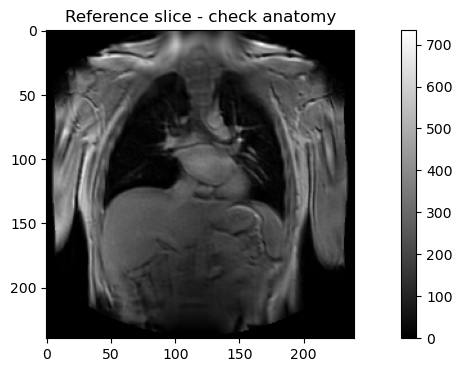

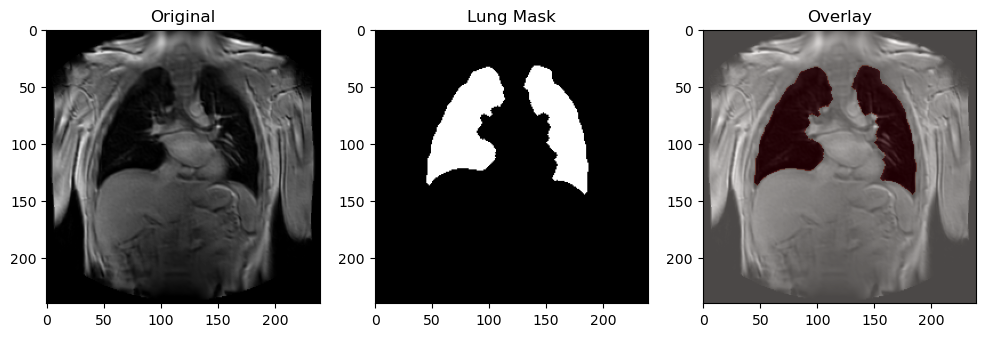

Processing 1/256
Processing 2/256
Processing 3/256
Processing 4/256
Processing 5/256
Processing 6/256
Processing 7/256
Processing 8/256
Processing 9/256
Processing 10/256
Processing 11/256
Processing 12/256
Processing 13/256
Processing 14/256
Processing 15/256
Processing 16/256
Processing 17/256
Processing 18/256
Processing 19/256
Processing 20/256
Processing 21/256
Processing 22/256
Processing 23/256
Processing 24/256
Processing 25/256
Processing 26/256
Processing 27/256
Processing 28/256
Processing 29/256
Processing 30/256
Processing 31/256
Processing 32/256
Processing 33/256
Processing 34/256
Processing 35/256
Processing 36/256
Processing 37/256
Processing 38/256
Processing 39/256
Processing 40/256
Processing 41/256
Processing 42/256
Processing 43/256
Processing 44/256
Processing 45/256
Processing 46/256
Processing 47/256
Processing 48/256
Processing 49/256
Processing 50/256
Processing 51/256
Processing 52/256
Processing 53/256
Processing 54/256
Processing 55/256
Processing 56/256
P

In [ ]:
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import SimpleITK as sitk
from skimage.morphology import binary_opening, binary_closing, remove_small_objects, disk
from skimage.measure import label, regionprops
from skimage.segmentation import clear_border
from scipy.ndimage import binary_fill_holes, gaussian_filter1d
from skimage.filters import threshold_otsu, threshold_triangle
from scipy.signal import find_peaks

# -----------------------------
# 1️⃣ Lung Mask Creation
# -----------------------------
def create_lung_mask_2d(img, body_threshold=0.1, lung_threshold_factor=0.5):
    img = img.astype(np.float32)
    img_norm = (img - img.min()) / (img.max() - img.min() + 1e-8)
    # Body mask
    body_mask = img_norm > body_threshold
    body_mask = binary_fill_holes(body_mask)
    body_mask = remove_small_objects(body_mask, min_size=5000)
    # Lung candidates
    lung_threshold = threshold_otsu(img_norm[body_mask]) * lung_threshold_factor
    lung_candidates = (img_norm < lung_threshold) & body_mask
    lung_candidates = clear_border(lung_candidates)
    lung_candidates = binary_opening(lung_candidates, disk(2))
    lung_candidates = binary_closing(lung_candidates, disk(3))
    lung_candidates = binary_fill_holes(lung_candidates)
    lung_candidates = remove_small_objects(lung_candidates, min_size=500)
    labeled = label(lung_candidates)
    props = sorted(regionprops(labeled), key=lambda r: r.area, reverse=True)
    final_mask = np.zeros_like(lung_candidates, dtype=bool)
    for prop in props[:2]:
        if 100 < prop.area < 50000:
            if prop.major_axis_length > 0:
                elongation = prop.minor_axis_length / prop.major_axis_length
                if 0.2 < elongation < 0.9:
                    final_mask[labeled == prop.label] = True

    # Fallback if segmentation fails
    if np.sum(final_mask) < 200:
        lung_threshold = threshold_triangle(img_norm[body_mask])
        lung_candidates = (img_norm < lung_threshold) & body_mask
        lung_candidates = binary_opening(lung_candidates, disk(2))
        lung_candidates = binary_closing(lung_candidates, disk(3))
        lung_candidates = remove_small_objects(lung_candidates, min_size=500)
        labeled = label(lung_candidates)
        props = sorted(regionprops(labeled), key=lambda r: r.area, reverse=True)
        for prop in props[:2]:
            if prop.area > 200:
                final_mask[labeled == prop.label] = True
    return final_mask

# -----------------------------
# 2️⃣ Load Data
# -----------------------------

# Change this to your local file of images
folder = r"C:\Users\georg\Documents\UCL\Year 3\Group Project\MRI Images\raw"

files = sorted([f for f in os.listdir(folder) if f.endswith(".nii.gz")])
num_frames = len(files)
print("Total frames:", num_frames)

# -----------------------------
# 3️⃣ Reference Frame
# -----------------------------
mid_idx = num_frames // 2
img_ref_vol = nib.load(os.path.join(folder, files[mid_idx])).get_fdata()
z_ref = img_ref_vol.shape[2] // 2
img_ref = np.rot90(img_ref_vol[:, :, z_ref]).astype(np.float32)

# Display reference slice
plt.figure(figsize=(12,4))
plt.imshow(img_ref, cmap='gray')
plt.title("Reference slice - check anatomy")
plt.colorbar()
plt.show()

# Create reference mask
ref_mask = create_lung_mask_2d(img_ref)

# Visualise mask
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(img_ref, cmap='gray')
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(ref_mask, cmap='gray')
plt.title("Lung Mask")

plt.subplot(1,3,3)
plt.imshow(img_ref, cmap='gray')
plt.imshow(ref_mask, alpha=0.3, cmap='Reds')
plt.title("Overlay")
plt.show()

# -----------------------------
# 4️⃣ Loop Through Frames
# -----------------------------
waveform = []
masks = []

for t, f in enumerate(files):
    print(f"Processing {t+1}/{num_frames}")
    img_vol = nib.load(os.path.join(folder, f)).get_fdata()
    z = img_vol.shape[2] // 2
    img_slice = np.rot90(img_vol[:, :, z]).astype(np.float32)
    mask = create_lung_mask_2d(img_slice)
    masks.append(mask)

    # Convert to SimpleITK
    img_ref_sitk = sitk.GetImageFromArray(img_ref)
    img_slice_sitk = sitk.GetImageFromArray(img_slice)
    img_ref_sitk = sitk.Cast(img_ref_sitk, sitk.sitkFloat32)
    img_slice_sitk = sitk.Cast(img_slice_sitk, sitk.sitkFloat32)

    # -----------------------------
    # Deformable Registration
    # -----------------------------
    mesh_size = [8,8]
    transform = sitk.BSplineTransformInitializer(img_ref_sitk, mesh_size)
    registration_method = sitk.ImageRegistrationMethod()
    registration_method.SetMetricAsMeanSquares()
    registration_method.SetOptimizerAsLBFGSB(
        gradientConvergenceTolerance=1e-5,
        numberOfIterations=50)

    registration_method.SetInterpolator(sitk.sitkLinear)
    registration_method.SetInitialTransform(transform, inPlace=False)
    final_transform = registration_method.Execute(
        img_ref_sitk,
        img_slice_sitk)

    # -----------------------------
    # Convert to Deformation Field
    # -----------------------------
    deformation_field = sitk.TransformToDisplacementField(
        final_transform,
        sitk.sitkVectorFloat64,
        img_ref_sitk.GetSize(),
        img_ref_sitk.GetOrigin(),
        img_ref_sitk.GetSpacing(),
        img_ref_sitk.GetDirection())

    # -----------------------------
    # Jacobian Determinant
    # -----------------------------
    jacobian_image = sitk.DisplacementFieldJacobianDeterminant(deformation_field)
    jacobian_array = sitk.GetArrayFromImage(jacobian_image)
    if np.any(ref_mask):
        avg_jacobian = np.mean(jacobian_array[ref_mask])
    else:
        avg_jacobian = np.mean(jacobian_array)
    waveform.append(avg_jacobian)

# -----------------------------
# 5️⃣ Process Waveform
# -----------------------------
waveform = np.array(waveform)
waveform = waveform - np.mean(waveform)
waveform_smooth = gaussian_filter1d(waveform, sigma=2)

# -----------------------------
# 6️⃣ Plot Respiratory Waveform
# -----------------------------
plt.figure(figsize=(12,5))
plt.plot(waveform_smooth, linewidth=2)
plt.xlabel("Frame")
plt.ylabel("Mean Lung Jacobian")
plt.title("Respiratory Waveform from Deformation Field")
plt.grid(True)
plt.show()

## Interpretation of the Respiratory Waveform

The graph shows the respiratory signal extracted from the MRI sequence using the **Jacobian determinant of the deformation field**.

### Axes

**X-axis — Frame**

- Each point represents one frame in the MRI time series.
- Moving from left to right corresponds to the progression of time during the scan.

**Y-axis — Mean Lung Jacobian**

The value plotted is the **average Jacobian determinant within the lung mask** for each frame:

$$
W(t) = \frac{1}{N} \sum_{(x,y)\in M} J(x,y)
$$

where:

- $J(x,y)$ is the Jacobian determinant at pixel $(x,y)$  
- $M$ is the lung mask  
- $N$ is the number of pixels inside the mask  
- $W(t)$ is the respiratory signal at frame $t$

The Jacobian determinant measures **local expansion or compression of tissue** caused by breathing.

### Interpretation of Values

- **Positive values** indicate lung expansion (inhalation)
- **Negative values** indicate lung compression (exhalation)
- **Values near zero** correspond to intermediate breathing states

### Breathing Cycles

Each oscillation in the waveform corresponds to one breathing cycle:

- **Peaks** represent maximum inhalation
- **Troughs** represent maximum exhalation

### Initial Transient

The sharp change at the beginning of the signal occurs because the first frame differs significantly from the reference frame used for registration. This requires a larger deformation during the initial alignment, producing a temporary spike in the Jacobian values before the signal stabilises.

<small>

## References

[1] S. Hu, E. A. Hoffman, and J. M. Reinhardt, “Automatic lung segmentation for accurate quantitation of volumetric X-ray CT images,” *IEEE Transactions on Medical Imaging*, vol. 20, no. 6, pp. 490–498, 2001.

[2] J. B. A. Maintz and M. A. Viergever, “A survey of medical image registration,” *Medical Image Analysis*, vol. 2, no. 1, pp. 1–36, 1998.

[3] D. Rueckert et al., “Nonrigid registration using free-form deformations: Application to breast MR images,” *IEEE Transactions on Medical Imaging*, vol. 18, no. 8, pp. 712–721, 1999.

[4] G. E. Christensen, R. D. Rabbitt, and M. I. Miller, “Deformable templates using large deformation kinematics,” *IEEE Transactions on Image Processing*, vol. 5, no. 10, pp. 1435–1447, 1996.

[5] B. Modat et al., “Fast free-form deformation using graphics processing units,” *Computer Methods and Programs in Biomedicine*, vol. 98, no. 3, pp. 278–284, 2010.

[6] J. Vandemeulebroucke, D. Sarrut, and P. Clarysse, “The POPI-model, a point-validated pixel-based breathing thorax model,” *Proc. IEEE Int. Symp. Biomedical Imaging*, pp. 211–214, 2007.

</small>